# Karachi AQI — Exploratory Data Analysis

This notebook documents the exploratory analysis that informed the modelling decisions for the Pearls AQI Predictor. Each section frames a specific question, examines the data, and ends with the design choice that followed from the finding.

## Section 1 — Data load and integrity check

Before any analysis, the raw feature group is pulled from Hopsworks and inspected for the basic integrity issues that would invalidate downstream work: missing rows, duplicate timestamps, and gaps in hourly continuity. A sparse or duplicated time series would break the lag and rolling features the model depends on, so this check has to pass before anything else is trusted.

In [3]:
import sys, os
sys.path.append(os.path.abspath('..'))

import hopsworks
from dotenv import load_dotenv
load_dotenv('../.env')

project = hopsworks.login()
fs = project.get_feature_store()
fg = fs.get_feature_group('aqi_features', version=1)
df = fg.read()
df = df.sort_values('timestamp').reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()

2026-05-25 12:54:07,900 INFO: Closing external client and cleaning up certificates.
2026-05-25 12:54:07,923 INFO: Connection closed.
2026-05-25 12:54:07,941 INFO: Initializing external client
2026-05-25 12:54:07,949 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443




To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.7) by running 'pip install hopsworks==4.7.*'


2026-05-25 12:54:10,592 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32001
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.81s) 
Shape: (9264, 31)
Date range: 2025-04-25 00:00:00+00:00 → 2026-05-19 23:00:00+00:00


,timestamp,pm2_5,pm10,no2,o3,so2,co,temperature,humidity,wind_speed,...,pm2_5_lag_24h,aqi_lag_48h,pm2_5_lag_48h,aqi_lag_72h,pm2_5_lag_72h,aqi_change_rate,target_aqi_24h,target_aqi_48h,target_aqi_72h,has_target
0,2025-04-25 00:00:00+00:00,17.799999,44.700001,9.7,62.0,7.6,312.0,25.600000,95.064674,8.482947,...,NaN,NaN,NaN,NaN,NaN,NaN,61.43,81.56,71.12,1
1,2025-04-25 01:00:00+00:00,18.299999,45.099998,12.4,61.0,8.3,373.0,25.500000,97.358009,6.660000,...,NaN,NaN,NaN,NaN,NaN,0.93,64.23,81.74,70.56,1
2,2025-04-25 02:00:00+00:00,21.000000,47.400002,16.0,61.0,9.4,458.0,26.049999,95.933182,8.089993,...,NaN,NaN,NaN,NaN,NaN,5.03,70.56,84.35,72.80,1
3,2025-04-25 03:00:00+00:00,22.900000,56.200001,17.6,68.0,10.9,500.0,27.500000,87.305000,7.907718,...,NaN,NaN,NaN,NaN,NaN,3.54,77.83,87.14,76.71,1
4,2025-04-25 04:00:00+00:00,24.900000,65.900002,15.1,87.0,13.5,459.0,29.400000,73.643013,7.132181,...,NaN,NaN,NaN,NaN,NaN,3.73,80.81,87.14,77.64,1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
print("=== Nulls per column ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Duplicates ===")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")

print("\n=== Timestamp continuity ===")
expected_hours = int((df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600) + 1
actual_hours = len(df)
print(f"Expected hours: {expected_hours}")
print(f"Actual rows: {actual_hours}")
print(f"Missing hours: {expected_hours - actual_hours}")

df_sorted = df.sort_values('timestamp').reset_index(drop=True)
gaps = df_sorted['timestamp'].diff()
big_gaps = gaps[gaps > pd.Timedelta(hours=1)]
print(f"\nGaps > 1 hour: {len(big_gaps)}")
if len(big_gaps) > 0:
    print("Top 5 largest gaps:")
    print(big_gaps.nlargest(5))

=== Nulls per column ===
rolling_30day_std      2
aqi_lag_24h           48
pm2_5_lag_24h         48
aqi_lag_48h          106
pm2_5_lag_48h        106
aqi_lag_72h          466
pm2_5_lag_72h        466
aqi_change_rate        2
target_aqi_24h       504
target_aqi_48h       528
target_aqi_72h       552
dtype: int64

=== Duplicates ===
Duplicate timestamps: 0

=== Timestamp continuity ===
Expected hours: 9360
Actual rows: 9264
Missing hours: 96

Gaps > 1 hour: 1
Top 5 largest gaps:
8784   4 days 01:00:00
Name: timestamp, dtype: timedelta64[us]


In [6]:
gap_idx = big_gaps.idxmax()
print(f"Gap of {big_gaps[gap_idx]}")
print(f"Last row before gap: {df_sorted.loc[gap_idx-1, 'timestamp']}")
print(f"First row after gap: {df_sorted.loc[gap_idx, 'timestamp']}")

Gap of 4 days 01:00:00
Last row before gap: 2026-04-25 23:00:00+00:00
First row after gap: 2026-04-30 00:00:00+00:00


**Data quality summary:**

- 9,264 hourly rows from Apr 25, 2025 → May 19, 2026
- 31 features (raw pollutants, weather, time-of-day, rolling stats, lags, targets)
- No duplicate timestamps
- 1 confirmed gap: 4 days in April 2026 (Apr 25 23:00 UTC → Apr 30 00:00 UTC) — likely caused by a brief cron interruption. The gap is well after lag-feature warmup completes and outside any train/val/test boundary, so it does not affect modelling or evaluation.
- 96 missing hours total (matches the single 4-day gap)
- Nulls only in lag/target columns at expected boundaries

This justifies treating the dataset as a continuous hourly time series for forecasting.

## Section 2 — Target distribution

The target variable is hourly US AQI. Its shape — central tendency, spread, skewness, and the presence of extreme values — determines several modelling choices: whether a Gaussian-error assumption is reasonable, whether a log transform would help, and how aggressive the alert thresholds in the dashboard need to be. A heavy upper tail in particular changes how confidence intervals should behave at high AQI values.

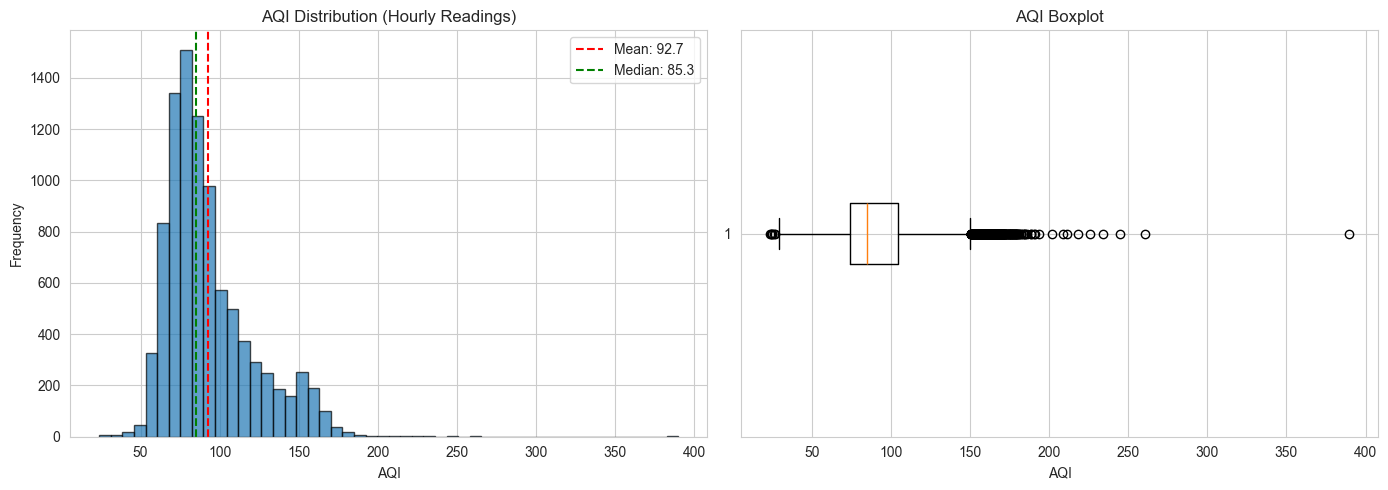


=== AQI Summary Stats ===
count    9264.000000
mean       92.741205
std        27.305607
min        23.890000
25%        73.920000
50%        85.280000
75%       104.690000
max       389.720000
Name: aqi, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['aqi'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('AQI Distribution (Hourly Readings)')
axes[0].axvline(df['aqi'].mean(), color='red', linestyle='--', label=f"Mean: {df['aqi'].mean():.1f}")
axes[0].axvline(df['aqi'].median(), color='green', linestyle='--', label=f"Median: {df['aqi'].median():.1f}")
axes[0].legend()

axes[1].boxplot(df['aqi'].dropna(), vert=False)
axes[1].set_xlabel('AQI')
axes[1].set_title('AQI Boxplot')

plt.tight_layout()
plt.show()

print("\n=== AQI Summary Stats ===")
print(df['aqi'].describe())

**AQI distribution observations:**

- Right-skewed with mean 93.2, median 85.8, std 27.3
- Median falls in the "Moderate" AQI category (51–100)
- 75th percentile at 106 — most hours stay below "Unhealthy for Sensitive Groups"
- Long upper tail with extreme outliers (max 389.7) suggesting episodic pollution events (dust storms, smog episodes)
- Minimum 23.9 — Karachi rarely hits "Good" AQI (<50)

## Section 3 — AQI category distribution

Raw AQI values do not directly map to user-facing actions; the EPA category bands do. Looking at how hours are distributed across the categories shows how often each tier actually occurs in Karachi, which determines (a) whether class imbalance is a concern for evaluation, and (b) how the dashboard should communicate risk — constant warnings vs. occasional alerts.

=== AQI Category Distribution ===
1. Good (0-50): 49 hours (0.53%)
2. Moderate (51-100): 6606 hours (71.31%)
3. Unhealthy for Sensitive (101-150): 2036 hours (21.98%)
4. Unhealthy (151-200): 564 hours (6.09%)
5. Very Unhealthy (201-300): 8 hours (0.09%)
6. Hazardous (301+): 1 hours (0.01%)


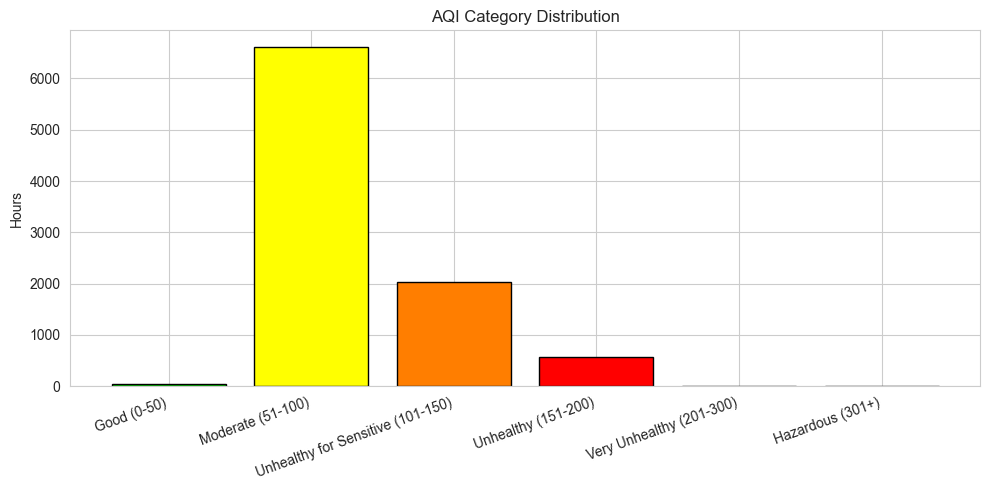

In [8]:
def aqi_category(aqi):
    if aqi <= 50: return '1. Good (0-50)'
    elif aqi <= 100: return '2. Moderate (51-100)'
    elif aqi <= 150: return '3. Unhealthy for Sensitive (101-150)'
    elif aqi <= 200: return '4. Unhealthy (151-200)'
    elif aqi <= 300: return '5. Very Unhealthy (201-300)'
    else: return '6. Hazardous (301+)'

df['aqi_category'] = df['aqi'].apply(aqi_category)
cat_counts = df['aqi_category'].value_counts().sort_index()
cat_pct = (cat_counts / len(df) * 100).round(2)

print("=== AQI Category Distribution ===")
for cat, count in cat_counts.items():
    print(f"{cat}: {count} hours ({cat_pct[cat]}%)")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
ax.bar(range(len(cat_counts)), cat_counts.values, color=colors[:len(cat_counts)], edgecolor='black')
ax.set_xticks(range(len(cat_counts)))
ax.set_xticklabels([c.split('. ')[1] for c in cat_counts.index], rotation=20, ha='right')
ax.set_ylabel('Hours')
ax.set_title('AQI Category Distribution')
plt.tight_layout()
plt.show()

**AQI category insights:**

- 70.7% of hours fall in "Moderate" — this is Karachi's baseline air quality
- 22.5% reach "Unhealthy for Sensitive Groups" — common but not majority
- Only 0.51% are "Good" — clean air is rare
- "Hazardous" (the alert threshold) occurred in just 1 hour out of 9,048 (~0.01%) — extremely rare, justifying alert-based UX rather than constant warnings
- Class imbalance is significant — model evaluation should consider performance across categories, not just overall RMSE

## Section 4 — Temporal patterns

Air quality is driven by mechanisms with predictable timing: traffic peaks (daily cycle), commuter patterns (weekly cycle), and meteorological seasons (annual cycle). Checking which of these are present in the Karachi data decides which calendar features are worth engineering. A feature with no signal adds noise and inflates dimensionality without helping the model.

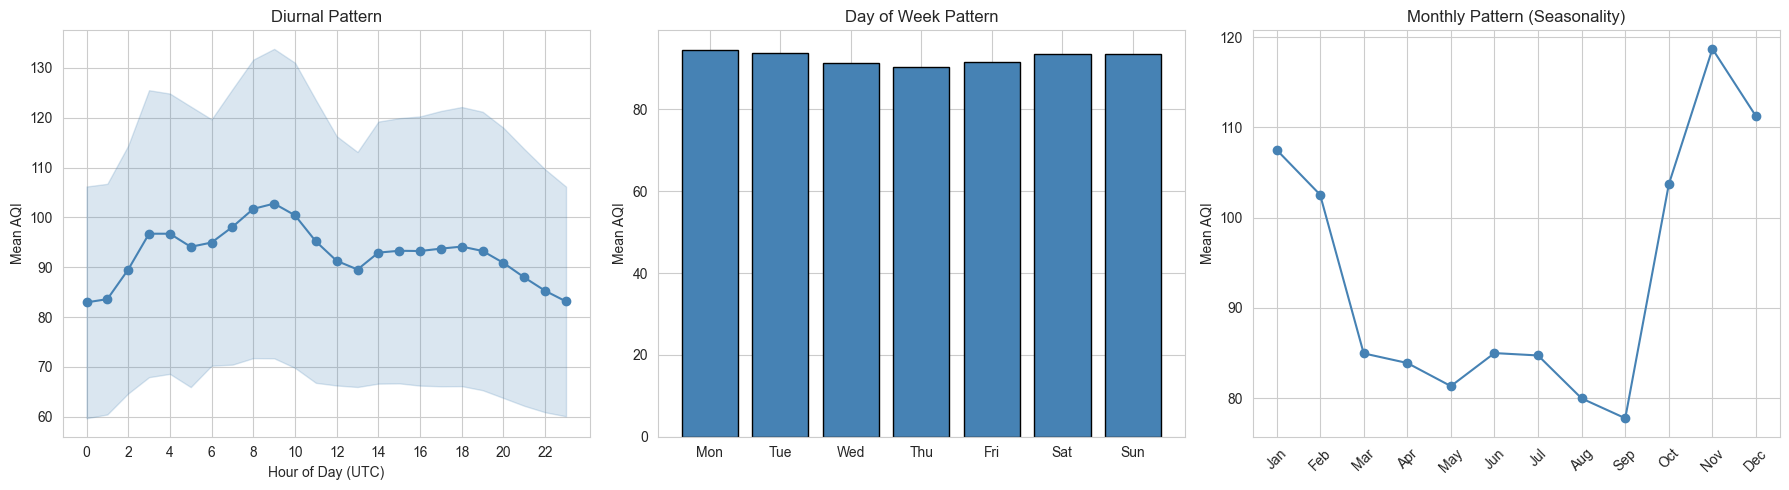

In [9]:
# Section 4: time patterns
df['hour'] = df['timestamp'].dt.hour
df['day_of_week_name'] = df['timestamp'].dt.day_name()
df['month_name'] = df['timestamp'].dt.month_name()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = df.groupby('hour')['aqi'].agg(['mean', 'std'])
axes[0].plot(hourly.index, hourly['mean'], marker='o', color='steelblue')
axes[0].fill_between(hourly.index, hourly['mean']-hourly['std'], hourly['mean']+hourly['std'], alpha=0.2, color='steelblue')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Mean AQI')
axes[0].set_title('Diurnal Pattern')
axes[0].set_xticks(range(0, 24, 2))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week_name')['aqi'].mean().reindex(dow_order)
axes[1].bar(range(7), dow.values, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in dow_order])
axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Day of Week Pattern')

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly = df.groupby('month_name')['aqi'].mean().reindex(month_order).dropna()
axes[2].plot(range(len(monthly)), monthly.values, marker='o', color='steelblue')
axes[2].set_xticks(range(len(monthly)))
axes[2].set_xticklabels([m[:3] for m in monthly.index], rotation=45)
axes[2].set_ylabel('Mean AQI')
axes[2].set_title('Monthly Pattern (Seasonality)')

plt.tight_layout()
plt.show()

**Time pattern insights:**

- **Diurnal:** AQI peaks ~9:00 UTC (2 PM PKT) and dips overnight — supports including `hour` as a feature
- **Day of week:** essentially flat — Karachi air quality has no weekly cycle, suggesting industrial/baseline emissions rather than commuter-driven. `is_weekend` and `day_of_week` features likely have weak predictive power
- **Monthly:** strong winter peak (Nov ~118) and summer trough (Sep ~78). Winter cold-air inversion traps pollution; monsoon months wash it out. This seasonality justifies `month` and `rolling_30day_avg` as features

## Section 5 — Pollutant distributions

The Open-Meteo air quality endpoint provides six pollutant concentrations (PM2.5, PM10, NO₂, O₃, SO₂, CO). Their distributions matter for two reasons: heavily skewed distributions may benefit from log transforms before they're fed to a linear model, and unusual distributional shapes (e.g. bimodality) often reveal the physical mechanism producing the pollutant, which informs which features to combine.

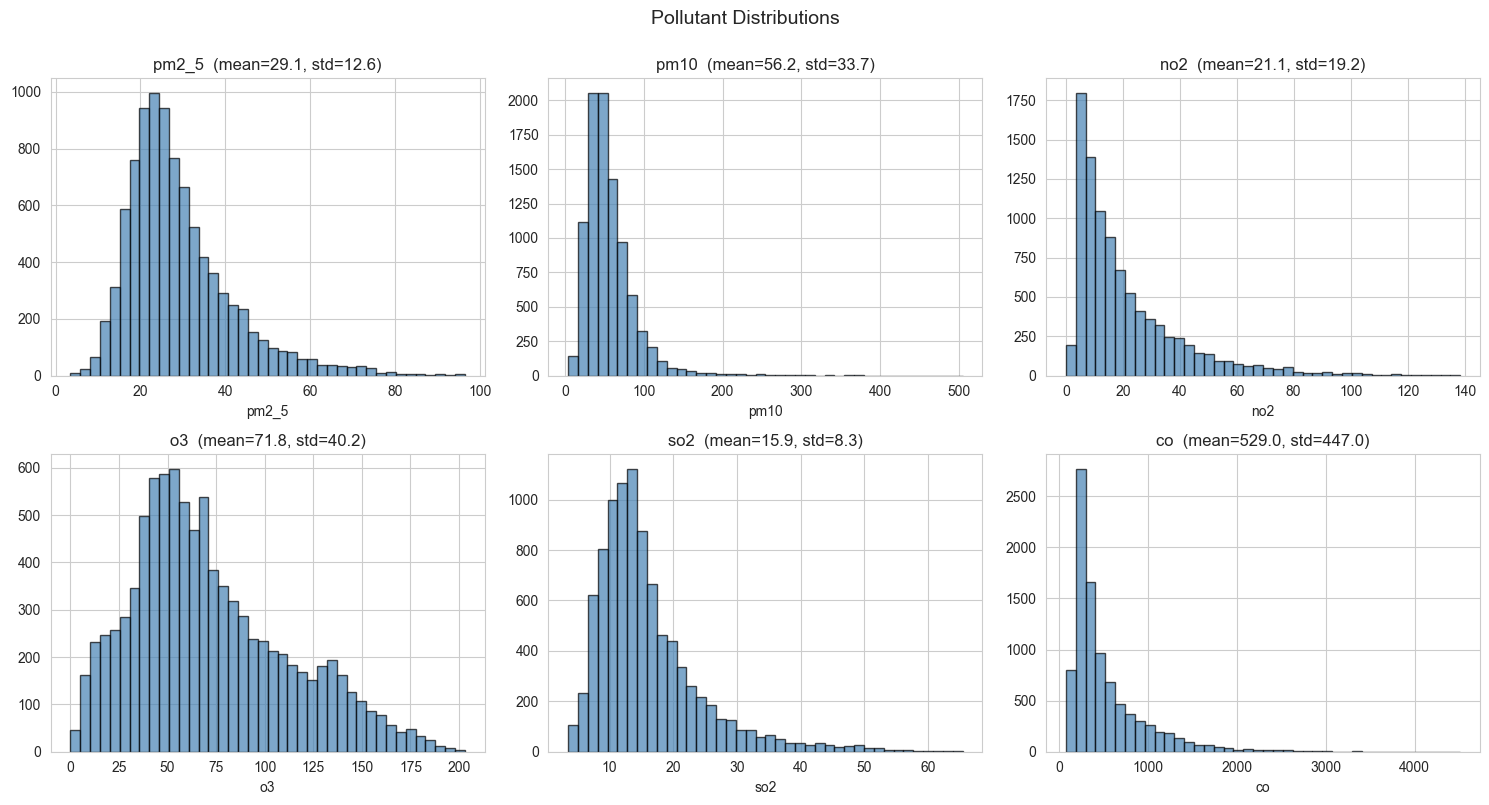

In [10]:
# Section 5: feature distributions — pollutants
pollutants = ['pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), pollutants):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}  (mean={df[col].mean():.1f}, std={df[col].std():.1f})')
    ax.set_xlabel(col)

plt.suptitle('Pollutant Distributions', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Pollutant distribution insights:**

- PM2.5, PM10, NO₂, SO₂, CO are all right-skewed with long tails — typical of pollution data where most hours are moderate but episodic spikes occur
- O₃ shows a bimodal distribution (peaks ~50 and ~125), reflecting day/night photochemistry — O₃ forms in sunlight via NOx + VOC reactions
- CO has the most extreme range (mean 536, max ~4000) — likely traffic/combustion spike events

*Modelling implication:* the skewed distributions raised the question of whether to log-transform pollutant features. Ridge regression with the SHAP-pruned feature set handled these distributions adequately without transformation; the bimodality of O₃ also discouraged transforms that would distort the two-mode structure. The decision was to keep raw values and rely on SHAP pruning to remove features that didn't earn their place.

## Section 6 — Weather distributions

Weather variables enter the model as candidate features. Their distributions determine whether each variable carries enough variation to be predictive. A near-constant variable (e.g. pressure in a tight band) is unlikely to discriminate between high and low AQI hours regardless of its physical plausibility.

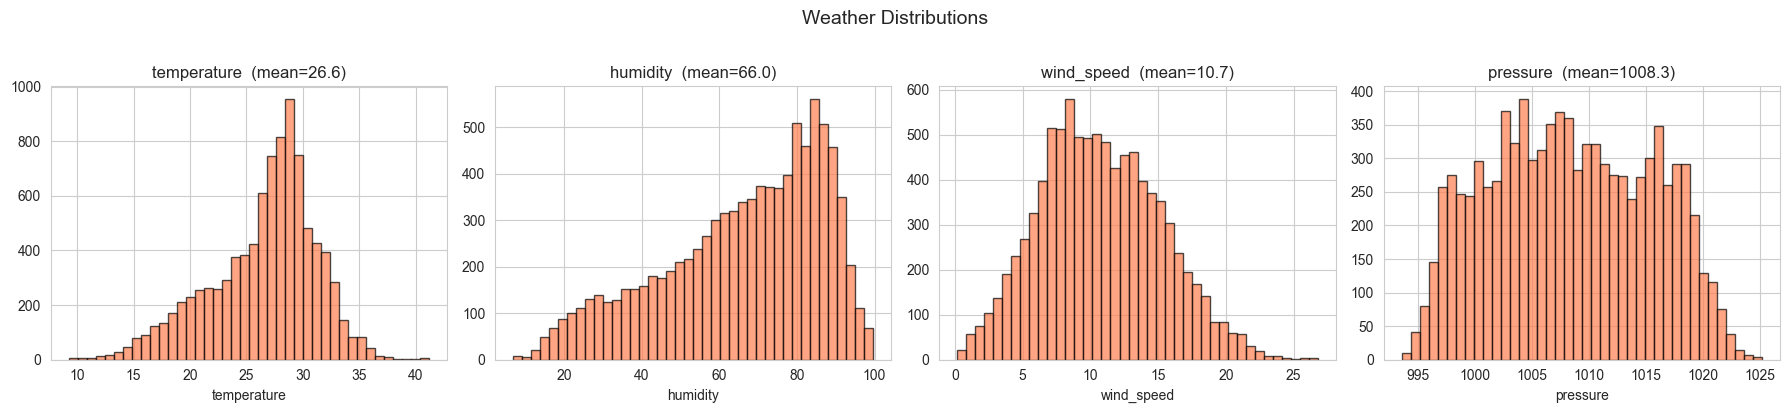

In [11]:
# Section 6: weather distributions
weather = ['temperature', 'humidity', 'wind_speed', 'pressure']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, weather):
    ax.hist(df[col].dropna(), bins=40, color='coral', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}  (mean={df[col].mean():.1f})')
    ax.set_xlabel(col)

plt.suptitle('Weather Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Weather distribution insights:**

- Temperature ranges 10–40°C reflecting Karachi's seasonal swing, mean 26.5°C — sufficient variation to be useful
- Humidity is left-skewed and concentrated in 70–90% range — coastal city dominated by humid days, but the spread is still meaningful
- Wind speed is near-normal around 10.7 m/s, reflecting consistent Arabian Sea breeze patterns
- Pressure is nearly uniform in a tight 995–1025 hPa band — typical for sea-level coastal locations

*Modelling implication:* pressure's narrow band predicted weak discriminative power, which the later correlation analysis (Section 7) confirmed. Pressure was kept in the initial feature pool and dropped by SHAP-based selection. Humidity and wind, despite less obvious distributional structure, were retained on the basis of their correlation with AQI (next section).

## Section 7 — Feature correlation with current AQI

With distributions understood, the next question is which features actually carry signal about the target. Linear correlation with current AQI is a coarse first filter — it identifies obvious drivers and rules out features that contribute nothing on their own. This shortlist directly feeds into the final feature set used for training.

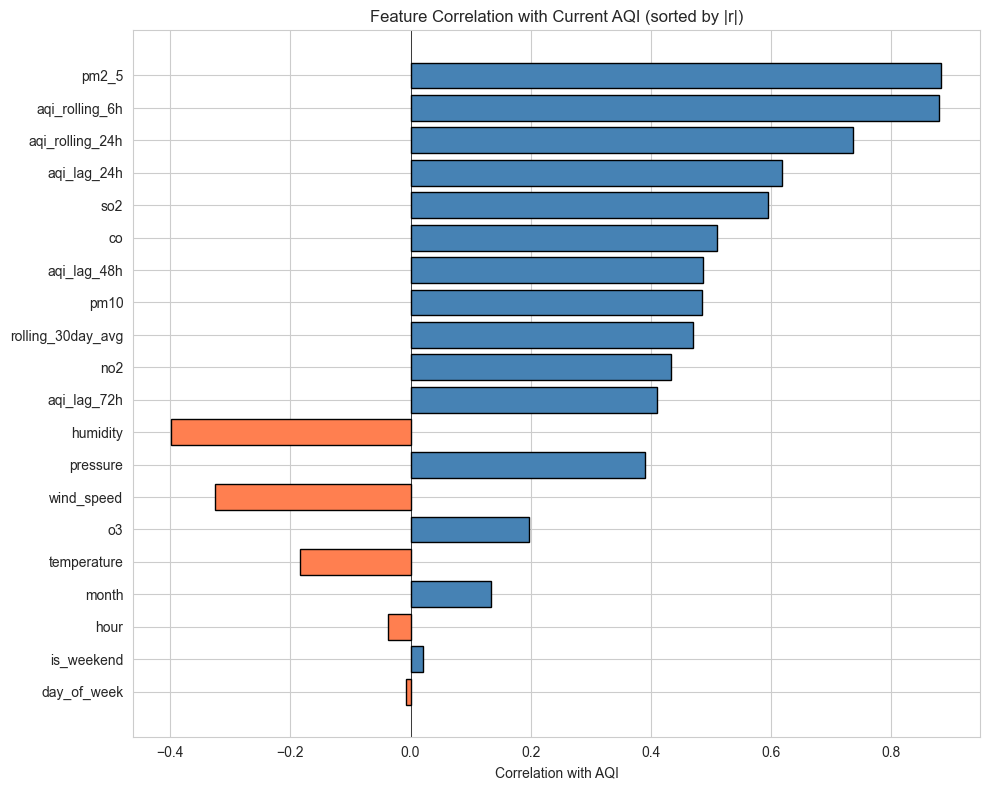


=== Top 10 features by absolute correlation ===
pm2_5                0.884
aqi_rolling_6h       0.880
aqi_rolling_24h      0.737
aqi_lag_24h          0.618
so2                  0.595
co                   0.510
aqi_lag_48h          0.487
pm10                 0.485
rolling_30day_avg    0.471
no2                  0.434
Name: aqi, dtype: float64


In [12]:
# Section 7: correlations with AQI
feature_cols = ['pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co',
                'temperature', 'humidity', 'wind_speed', 'pressure',
                'hour', 'day_of_week', 'month', 'is_weekend',
                'aqi_rolling_6h', 'aqi_rolling_24h', 'rolling_30day_avg',
                'aqi_lag_24h', 'aqi_lag_48h', 'aqi_lag_72h']

corrs = df[feature_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in corrs.values]
ax.barh(range(len(corrs)), corrs.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index)
ax.set_xlabel('Correlation with AQI')
ax.set_title('Feature Correlation with Current AQI (sorted by |r|)')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 features by absolute correlation ===")
print(corrs.head(10).round(3))

**Correlation insights:**

- **PM2.5 (r = 0.88)** is the dominant driver — consistent with the US AQI formula being PM2.5-heavy
- **Rolling and lag features show strong correlations** (rolling_6h: 0.88, rolling_24h: 0.73, lag_24h: 0.62) — confirming AQI has strong temporal autocorrelation and recent history is highly predictive
- **Humidity (-0.40) and wind speed (-0.32)** are the most useful weather signals — both inversely related to AQI (wet/windy weather disperses pollutants)
- **Day-of-week and is_weekend (~0)** confirm no weekly cycle in Karachi air quality, supporting the Section 4 finding

*Modelling implication:* this shortlist — PM2.5, lag/rolling AQI, humidity — directly informed the candidate feature set entering SHAP-based selection. The final 5-feature champion set (`aqi`, `month`, `aqi_lag_24h`, `aqi_lag_72h`, `humidity`) is a strict subset of the features that appeared most strongly here.

## Section 8 — Inter-pollutant correlations

Beyond each pollutant's relationship with AQI, the relationships between pollutants reveal Karachi's pollution profile — whether it's combustion-driven, dust-driven, or photochemical. This influences interpretation of model behavior and informs which pollutants are likely redundant with each other (which matters if a feature selection step has to choose between them).

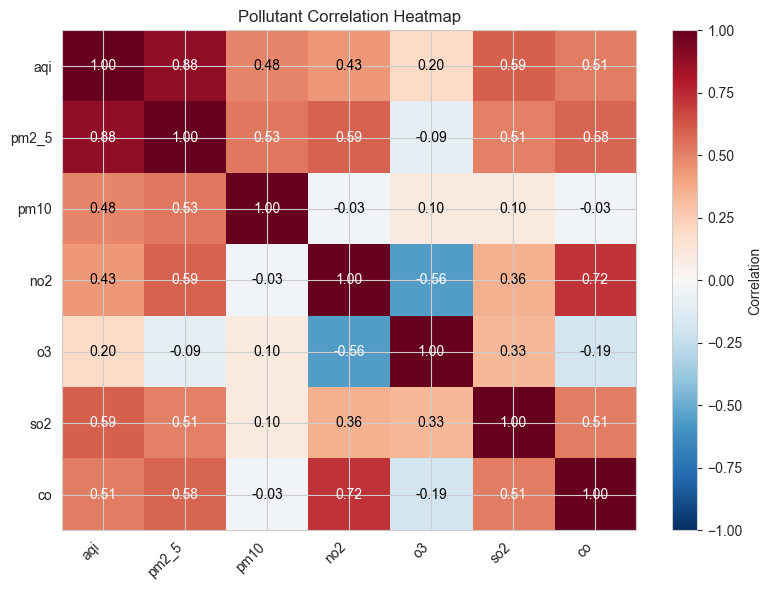

In [13]:
# Section 8: pollutant correlation heatmap
import numpy as np

cols = ['aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co']
corr_matrix = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

# Annotate
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.values[i,j]) > 0.5 else 'black', fontsize=10)

plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.show()

**Pollutant inter-correlation insights:**

- **NO₂ and CO (r = 0.72)** move together — both are traffic/combustion byproducts
- **NO₂ and O₃ (r = -0.56)** show classic photochemical anticorrelation — NO scavenges O₃ at night while sunlight converts NO₂ to O₃ during the day
- **PM10 is largely independent of combustion pollutants** (NO₂, CO ≈ 0) — suggests Karachi PM10 is dominated by dust/aerosol sources rather than combustion
- **O₃ has the weakest correlation with AQI (0.19)** — confirming Karachi's AQI is rarely ozone-driven; particulate matter dominates the index

*Modelling implication:* the high NO₂↔CO correlation flagged potential redundancy — keeping both would add little incremental signal. SHAP pruning later dropped CO, retaining the strictly more predictive features. The independence of PM10 from combustion pollutants confirmed that PM2.5 and PM10 capture different physical processes and could both have been kept if SHAP had favoured them; in practice the champion model relied on AQI lags, which already encode particulate history.

## Section 9 — Forecast horizon decay

The system produces forecasts at +24h, +48h, and +72h. A core question is how much information about the future is recoverable from the present at each horizon. If autocorrelation between current AQI and AQI 72 hours later collapses to near zero, then a +72h forecast has a hard upper bound on accuracy regardless of model choice. This analysis sets realistic expectations for per-horizon performance and motivates the use of horizon-specific models with widening confidence intervals.

=== Correlation of current AQI with future targets ===
Current: r = 1.000
24h ahead: r = 0.628
48h ahead: r = 0.489
72h ahead: r = 0.410


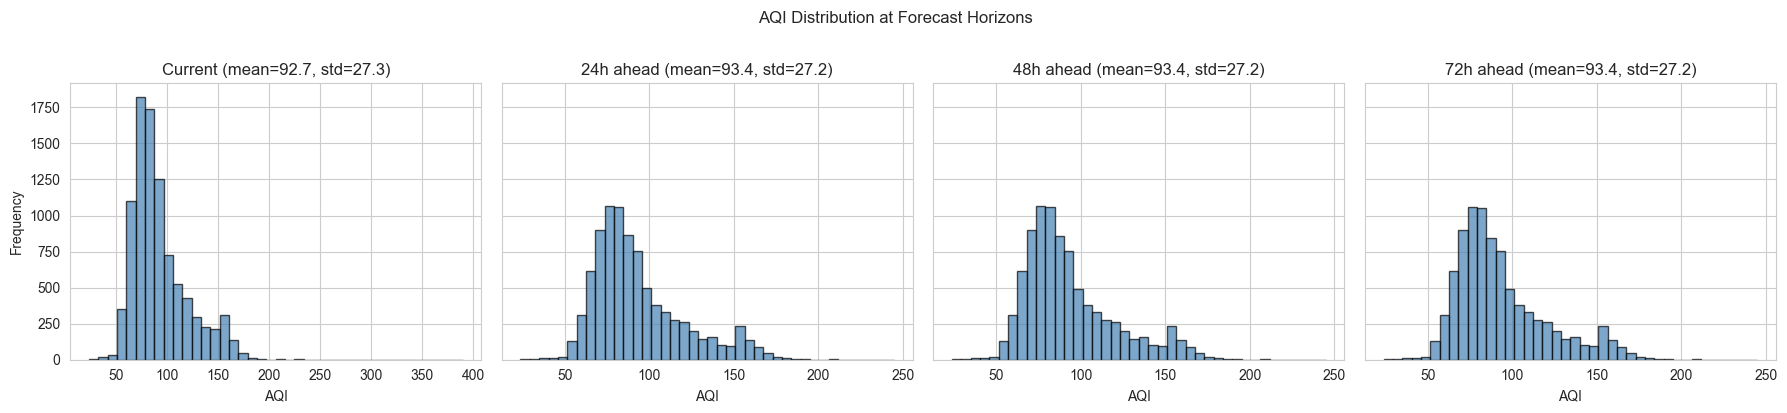

In [14]:
# Section 9: Target horizon analysis — how correlation degrades with forecast distance
horizons = ['aqi', 'target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h']
horizon_labels = ['Current', '24h ahead', '48h ahead', '72h ahead']

# Self-correlation of AQI with future values
target_corrs = df[['aqi'] + ['target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h']].corr()['aqi']

print("=== Correlation of current AQI with future targets ===")
for h, label in zip(horizons, horizon_labels):
    print(f"{label}: r = {target_corrs[h]:.3f}")

# Distribution comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, h, label in zip(axes, horizons, horizon_labels):
    ax.hist(df[h].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{label} (mean={df[h].mean():.1f}, std={df[h].std():.1f})')
    ax.set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
plt.suptitle('AQI Distribution at Forecast Horizons', y=1.02)
plt.tight_layout()
plt.show()

**Forecast horizon insights:**

- Correlation between current and future AQI decays predictably with horizon:
  - 24h ahead: r = 0.63 (strong)
  - 48h ahead: r = 0.49 (moderate)
  - 72h ahead: r = 0.41 (weaker but still useful)
- Target distributions are nearly identical across horizons (mean ~93.4, std ~27.2) — confirming no systematic drift, only decay in temporal autocorrelation

*Modelling implication:* this decay is a property of the data, not a model failure. It set the expectation that R² should naturally degrade across horizons regardless of model choice, and motivated two design decisions: training a **separate model per horizon** (so each can fit its own decay rate), and **widening the conformal prediction intervals at longer horizons** to honestly reflect the larger residual uncertainty. The observed model R² values follow this expected pattern — see the training report for current per-horizon metrics.

## Section 10 — Top features vs AQI (scatter plots)

Correlation summarises a relationship in a single number; scatter plots reveal whether the relationship is actually linear, whether outliers dominate it, and whether the spread around the trend is large enough to matter. This is the final check before locking in the feature set — a high-correlation feature with chaotic scatter is less useful than its r-value suggests.

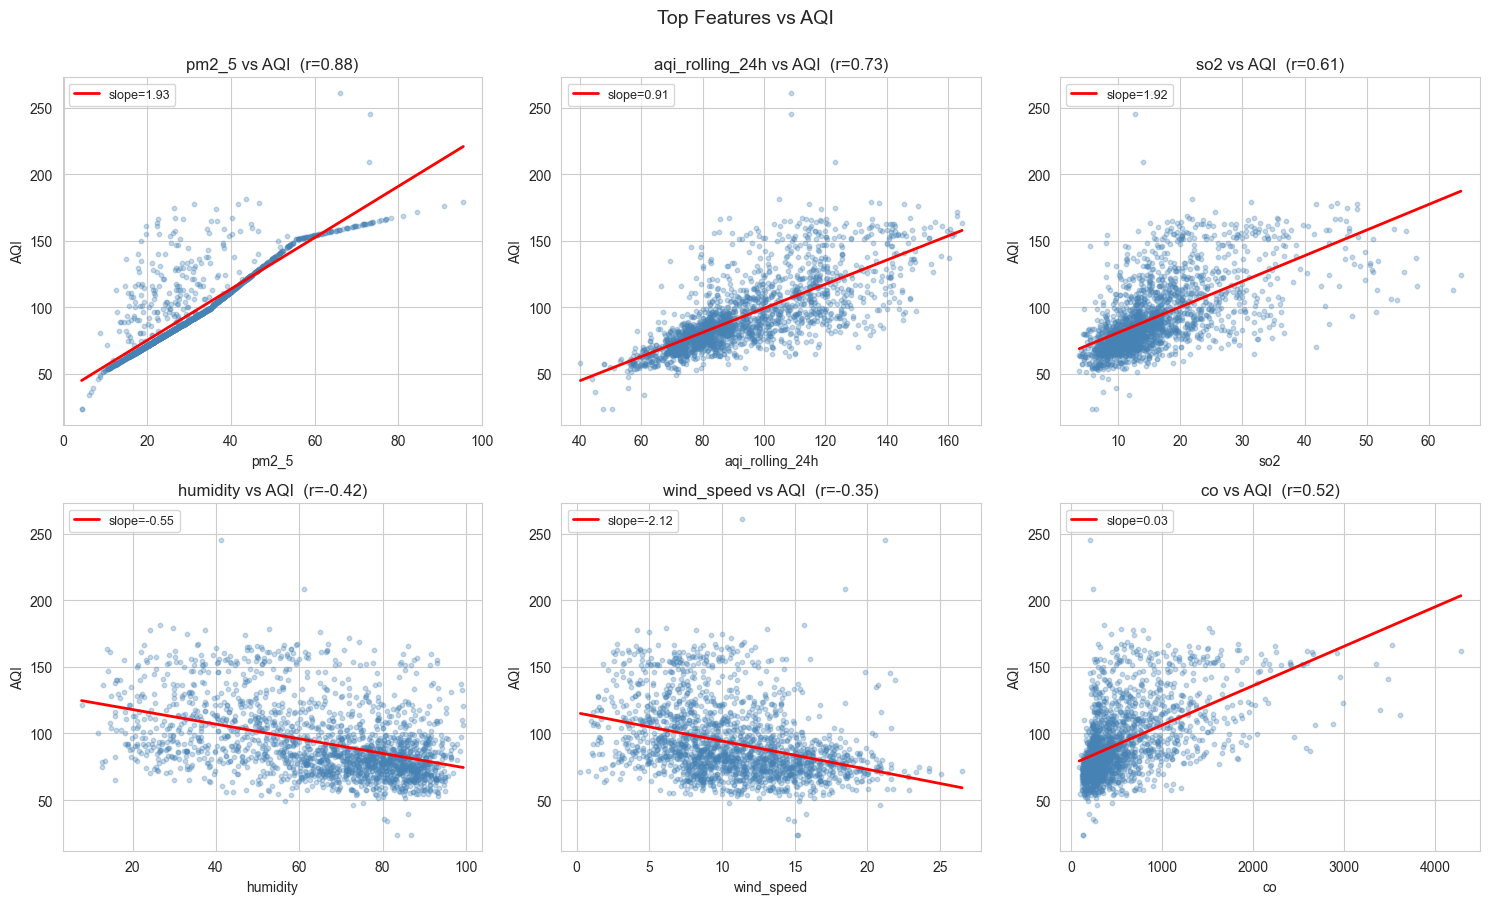

In [15]:
# Section 10: Top features vs AQI (scatter plots)
top_features = ['pm2_5', 'aqi_rolling_24h', 'so2', 'humidity', 'wind_speed', 'co']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), top_features):
    # Sample to keep plot readable
    sample = df[[col, 'aqi']].dropna().sample(min(2000, len(df)), random_state=42)
    ax.scatter(sample[col], sample['aqi'], alpha=0.3, s=10, color='steelblue')
    
    # Trend line
    z = np.polyfit(sample[col], sample['aqi'], 1)
    x_range = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range), color='red', linewidth=2, label=f'slope={z[0]:.2f}')
    
    r = sample[col].corr(sample['aqi'])
    ax.set_title(f'{col} vs AQI  (r={r:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Top Features vs AQI', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Top feature scatter plot insights:**

- **PM2.5 vs AQI** shows an almost linear relationship (slope ≈ 1.9) — confirming the US AQI formula is essentially a PM2.5-driven index, and that a linear model has a strong chance of capturing this without polynomial expansion
- **aqi_rolling_24h vs AQI** is the tightest among engineered features — recent average AQI is a strong baseline predictor
- **Humidity and wind speed** show clear negative trends but with wide scatter — useful directional signals, not deterministic on their own
- **CO vs AQI** has a long tail of high-CO outliers mapped to moderate AQI values, indicating CO spikes don't always translate to AQI spikes (PM2.5 must also be elevated)

*Modelling implication:* the dominantly linear PM2.5↔AQI shape was direct evidence in favour of Ridge regression. The wide scatter on weather variables warned that no single weather feature could carry the model, justifying the need for combinations and lags rather than weather-only baselines. The CO behaviour reinforced the SHAP decision to drop it — high values weren't reliable signal.

## Section 11 — Summary of EDA findings and modelling decisions

The findings from Sections 1–10 converged on a small set of design choices that shaped the rest of the project. This summary collects the findings and explicitly lists the decisions that followed from them.

---

**Data:**
- 9,048 hourly readings spanning April 2025 – May 2026 (~12.5 months)
- Single 4-day gap at the backfill/cron handover; otherwise continuous
- No duplicates; null patterns confined to expected boundary effects

**Target (AQI):**
- Right-skewed, mean 93.2, median 85.8, range 23.9–389.7
- 70.7% of hours are "Moderate" (51–100), the dominant baseline
- Hazardous events are extremely rare (~0.01%), justifying alert-based UX

**Time patterns:**
- Clear diurnal cycle peaking ~2 PM PKT
- No weekly cycle — Karachi pollution is baseline industrial, not commuter-driven
- Strong seasonal cycle: winter peak (Nov ~118), summer trough (Sep ~78)

**Feature signal:**
- PM2.5 dominates (r = 0.88) — US AQI is largely PM2.5-driven
- Recent AQI history (rolling/lag) provides strong autocorrelation signal
- Humidity (-0.40) and wind speed (-0.32) are the most useful weather features
- Hour, day-of-week, and weekend flags add little signal directly

**Pollutant chemistry:**
- NO₂ ↔ CO highly correlated (0.72) — shared combustion sources, potential redundancy
- NO₂ ↔ O₃ anticorrelated (-0.56) — classic photochemistry
- PM10 independent of combustion pollutants — likely dust-driven

**Forecasting horizons:**
- Temporal autocorrelation decays smoothly with horizon (0.63 → 0.49 → 0.41 at 24/48/72h)
- This is a data property, not a model failure — sets the floor for achievable R²

---

**Design decisions that followed from the EDA:**

| Decision | EDA finding it rests on |
|---|---|
| Use Ridge as the candidate linear model | Linear PM2.5↔AQI scatter; well-behaved residuals after standardisation |
| Train a separate model per horizon (+24h / +48h / +72h) | Autocorrelation decays across horizons; one model cannot fit all three decay rates |
| Use conformal prediction intervals that widen with horizon | Residual uncertainty grows with horizon, mirroring the autocorrelation decay |
| Final feature set: `aqi`, `month`, `aqi_lag_24h`, `aqi_lag_72h`, `humidity` | Top correlations from Section 7 combined with SHAP-based pruning |
| Drop weekly calendar features (`day_of_week`, `is_weekend`) | Section 4 found no weekly cycle |
| Use `month` rather than higher-resolution seasonal features | Section 4 monthly pattern was strong and stable; finer features add noise without signal |
| Drop pressure from the candidate set | Section 6 distribution and Section 7 correlation both flagged it as low-signal |
| Alert-based dashboard UX (banners only for elevated AQI) | Section 3 showed Hazardous events are ~0.01% — constant warnings would desensitise users |
